In [1]:
import os
import sys
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt


from kineticanalysis.generator.generator_track import (generate_tracks, generate_one_track)
from kineticanalysis.analysis.analysis_track import single_track_analysis, check_track_validity

In [2]:
path_save = "/home/u2175049/Documents/Code/KineticAnalysis/notebook/figures/"
path = "/mnt/sda1/Sophie/2-KineticAnalysisData/2-Datas/05-Modelling/01-TrackLength/"

In [32]:
prot_aa_size = {
    "32xsuntag": 796,  #768/32=24 , left 28
    "linker": 4,
    "twist": 490,
    "ilp4": 134,
    "snail": 390,
    "similar_prot":800,
    "very_long_prot":3000, 
}

In [33]:
prot_length = prot_aa_size["32xsuntag"]+prot_aa_size["very_long_prot"]
elongation_rate = 5

In [34]:
for i in range(200):
    x_global, y_global, y_start_prot = generate_one_track(prot_length = prot_aa_size["very_long_prot"], 
                                                      suntag_length = prot_aa_size["32xsuntag"], 
                                                      nb_suntag=32, 
                                                      fluo_one_suntag=4, 
                                                      translation_rate=elongation_rate, 
                                                      binding_rate=0.05,
                                                      step = 0.1,
                                                      length=85000, 
                                                       remove_point_beginning=10000)
    if i == 0:
        datas = pd.DataFrame({"FRAME":x_global,
                          "MEAN_INTENSITY_CH1":y_global,
                          "TRACK_ID" : i
                             })
    else:
        datas = pd.concat([datas, 
                           pd.DataFrame({"FRAME":x_global,
                          "MEAN_INTENSITY_CH1":y_global,
                          "TRACK_ID" : i
                             })], ignore_index=True)

datas.to_csv(os.path.join(path, "datas_track_length_translation_rate_5_long.csv"))

In [6]:
# datas = pd.read_csv(os.path.join(path, "datas_track_length.csv"), index_col="Unnamed: 0")
datas

,FRAME,MEAN_INTENSITY_CH1,TRACK_ID
0,0.0,785.608040,0
1,0.1,786.331658,0
2,0.2,787.055276,0
3,0.3,787.778894,0
4,0.4,788.502513,0
...,...,...,...
167999995,83999.5,705.286432,199
167999996,83999.6,705.688442,199
167999997,83999.7,706.090452,199
167999998,83999.8,706.492462,199


In [7]:
datas = pd.read_csv(os.path.join(path, "datas_track_length_translation_rate_5_ilp4.csv"), index_col="Unnamed: 0")

In [35]:
# Utiliser t comme base de la boucle
prot_length = prot_aa_size["32xsuntag"]+prot_aa_size["very_long_prot"]
first = True

for t in [10,30,50,100]:
# t = 50

    dt = t*0.1
    for length_track in [30,60,300,600,1200,1800,2700,3600]:
        print(length_track)
        
        for i in range(200):
            datas2 = datas[datas["TRACK_ID"]==i][::t][:length_track]
            datas2["FRAME"] = np.arange(length_track)
            if (len(np.unique(datas2["MEAN_INTENSITY_CH1"])) > 1) & (len(datas2) in [30,60,300,600,1200,1800,2700,3600]):
                
                (valid, x, y, x_fix, y_fix) = check_track_validity(datas2,
                                                       i,
                                                       normalise_intensity=1,
                                                       delta_t=dt,
                                                       rtol=1e-1,
                                                       nb_missing_point=0,
                                                       )
    
                
                (x_auto, 
                 y_auto, 
                 k, c,
                 elongation_r, 
                 translation_init_r,
                 perr) = single_track_analysis(x, 
                                             y, 
                                             delta_t = dt,
                                             protein_size=prot_aa_size["very_long_prot"],
                                             suntag_size =prot_aa_size["32xsuntag"], 
                                             repetition_suntag = 32,
                                             mm=None,
                                             method="approx",
                                             simulation=True)
                if first:
                    results = pd.DataFrame({"elongation_r":elongation_r, 
                                            "init_translation_r":translation_init_r, 
                                            "dt":dt,
                                            "long_track":datas2.shape[0],
                                            "k":k,
                                            "c":c,
                                           "id":i},
                                          index=[0])
                    first = False
                
                else:
                    results = pd.concat([results, 
                                    pd.DataFrame({"elongation_r":elongation_r, 
                                                  "init_translation_r":translation_init_r, 
                                                  "dt":dt, 
                                                  "long_track":datas2.shape[0],
                                                  "k":k,
                                                    "c":c,
                                                  "id":i}, index=[0])
                                    ], ignore_index=True)
                        
results.to_csv(os.path.join(path, "result_track_length_translation_rate_5_long.csv"))

30
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125

/home/u2175049/anaconda3/envs/kineticGUI/lib/python3.11/site-packages/kineticanalysis/analysis/analysis_track.py:90: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = optimize.curve_fit(function_approx,


125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32

In [81]:
t=10
dt = t*0.1
nb_point = int(60/dt)
datas[datas["TRACK_ID"]==i][::t][:nb_point]

,FRAME,MEAN_INTENSITY_CH1,TRACK_ID
419160000,0.0,2126.954774,499
419160010,1.0,2134.753769,499
419160020,2.0,2141.989950,499
419160030,3.0,2149.226131,499
419160040,4.0,2156.462312,499
419160050,5.0,2163.698492,499
419160060,6.0,2170.934673,499
419160070,7.0,2177.527638,499
419160080,8.0,2056.040201,499
419160090,9.0,2062.472362,499


In [82]:
t = 100
dt = t*0.1
nb_point = int(60/dt)
datas[datas["TRACK_ID"]==i][::t][:nb_point]

,FRAME,MEAN_INTENSITY_CH1,TRACK_ID
419160000,0.0,2126.954774,499
419160100,10.0,2068.904523,499
419160200,20.0,2133.226131,499
419160300,30.0,2079.758794,499
419160400,40.0,2162.492462,499
419160500,50.0,2109.909548,499


In [36]:
# Utiliser durée de la track comme base de la boucle
prot_length = prot_aa_size["32xsuntag"]+prot_aa_size["very_long_prot"]
first = True

#[1, 5, 10, 30, 50, 60, 100] in min
# in sec
for length_track in [60, 300, 600, 1800, 3000, 3600, 6000]:
    print(length_track)
    for t in [10,30,50,100, 300, 600]:
        dt = t*0.1
        nb_point = int(length_track/dt)
        print(t, nb_point)
        for i in range(200):
            datas2 = datas[datas["TRACK_ID"]==i][::t][:nb_point]
            datas2["FRAME"] = np.arange(nb_point)
            if (len(np.unique(datas2["MEAN_INTENSITY_CH1"])) > 2):
                
                (valid, x, y, x_fix, y_fix) = check_track_validity(datas2,
                                                       i,
                                                       normalise_intensity=1,
                                                       delta_t=dt,
                                                       rtol=1e-1,
                                                       nb_missing_point=0,
                                                       )
    
                
                (x_auto, y_auto, k, c,elongation_r, translation_init_r,perr) = single_track_analysis(x, 
                                                                                                     y, 
                                                                                                     delta_t = dt,
                                                                                                     protein_size=prot_aa_size["very_long_prot"],
                                                                                                     suntag_size =prot_aa_size["32xsuntag"], 
                                                                                                     repetition_suntag = 32,
                                                                                                     mm=None,
                                                                                                     # method="exact",
                                                                                                     method="approx",
                                                                                                     simulation=True)
                if first:
                    results = pd.DataFrame({"elongation_r":elongation_r, 
                                            "init_translation_r":translation_init_r, 
                                            "dt":dt,
                                            "long_track":datas2.shape[0],
                                            "k":k,
                                            "c":c,
                                           "id":i},index=[0])
                    first = False
                
                else:
                    results = pd.concat([results, 
                                    pd.DataFrame({"elongation_r":elongation_r, 
                                                  "init_translation_r":translation_init_r, 
                                                  "dt":dt, 
                                                  "long_track":datas2.shape[0],
                                                  "k":k,
                                                    "c":c,
                                                  "length_track":length_track,
                                                  "nb_point":nb_point,
                                                  "id":i}, index=[0])
                                    ], ignore_index=True)
                        
results.to_csv(os.path.join(path, "result_track_length_translation_rate_5_long_v2.csv"))

60
10 60
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 

/home/u2175049/anaconda3/envs/kineticGUI/lib/python3.11/site-packages/kineticanalysis/analysis/analysis_track.py:90: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = optimize.curve_fit(function_approx,


125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32

/home/u2175049/anaconda3/envs/kineticGUI/lib/python3.11/site-packages/kineticanalysis/analysis/analysis_track.py:90: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = optimize.curve_fit(function_approx,
/home/u2175049/anaconda3/envs/kineticGUI/lib/python3.11/site-packages/kineticanalysis/analysis/analysis_track.py:90: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = optimize.curve_fit(function_approx,


125 32
125 32
125 32
125 32


...

/home/u2175049/anaconda3/envs/kineticGUI/lib/python3.11/site-packages/kineticanalysis/analysis/analysis_track.py:90: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = optimize.curve_fit(function_approx,
/home/u2175049/anaconda3/envs/kineticGUI/lib/python3.11/site-packages/kineticanalysis/analysis/analysis_track.py:90: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = optimize.curve_fit(function_approx,


125 32
125 32


/home/u2175049/anaconda3/envs/kineticGUI/lib/python3.11/site-packages/kineticanalysis/analysis/analysis_track.py:90: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = optimize.curve_fit(function_approx,
/home/u2175049/anaconda3/envs/kineticGUI/lib/python3.11/site-packages/kineticanalysis/analysis/analysis_track.py:90: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = optimize.curve_fit(function_approx,


125 32
125 32


/home/u2175049/anaconda3/envs/kineticGUI/lib/python3.11/site-packages/kineticanalysis/analysis/analysis_track.py:90: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = optimize.curve_fit(function_approx,


In [24]:
(len(np.unique(datas2["MEAN_INTENSITY_CH1"])) > 2)

False

In [60]:
results = pd.read_csv(os.path.join(path, "results_dt_track_length_translation_rate_5_nb_point.csv"), index_col="Unnamed: 0")

In [37]:
results.groupby(by=['dt', 'length_track'])[['elongation_r','init_translation_r', 'k', 'c', "long_track", "nb_point"]].mean()

elongation_r  init_translation_r           k           c  \
dt   length_track                                                             
1.0  60.0            239.220431          362.503237   15.225837  362.503237   
     300.0            43.985222           12.199689   79.213566   12.199689   
     600.0            23.208667            2.968556  151.935488    2.968556   
     1800.0            8.584656            0.301000  400.983409    0.301000   
     3000.0            6.289477            0.147519  546.348681    0.147519   
     3600.0            6.023481            0.125044  559.874269    0.125044   
     6000.0            5.151462            0.087304  665.322251    0.087304   
3.0  60.0            247.994872          385.208597   15.049865  385.208597   
     300.0            44.151198           12.193628   79.013385   12.193628   
     600.0            23.251651            2.959943  151.837018    2.959943   
     1800.0            8.586509            0.300822  400.929034    0.300822   
     3000.0            6.292159            0.147579  546.324738    0.147579   
     3600.0            6.028244            0.125186  559.723331    0.125186   
     6000.0            5.151281            0.087301  665.231145    0.087301   
5.0  60.0            254.072416          392.444030   14.617555  392.444030   
     300.0            44.645367           12.492261   78.644495   12.492261   
     600.0            29.299552            3.049077  149.642325    3.049077   
     1800.0           77.309467            0.698476  349.253618    0.698476   
     3000.0           70.040546            0.577216  481.336194    0.577216   
     3600.0           38.985332            0.331745  522.041688    0.331745   
     6000.0           47.092433            0.363475  615.389581    0.363475   
10.0 60.0            212.681189          313.475341   15.549951  313.475341   
     300.0            79.889958           13.269962   68.371339   13.269962   
     600.0           134.094605            5.201018   98.953562    5.201018   
     1800.0          322.134846            5.194544  104.019686    5.194544   
     3000.0          402.277841            6.237157   60.260554    6.237157   
     3600.0          422.321403            6.506261   43.675154    6.506261   
     6000.0          460.609369            6.818960   13.053714    6.818960   
30.0 300.0           159.040979           22.900239   26.784208   22.900239   
     600.0           243.694530           14.634135   16.582045   14.634135   
     1800.0          394.092805            8.828657    8.715796    8.828657   
     3000.0          435.553247            7.664715    7.397822    7.664715   
     3600.0          444.056292            7.435977    7.148880    7.435977   
     6000.0          464.501213            6.981303    6.699244    6.981303   
60.0 300.0           158.780068           27.794448   25.578180   27.794448   
     600.0           245.165580           15.548450   15.671808   15.548450   
     1800.0          393.706250            8.846681    8.731106    8.846681   
     3000.0          435.530504            7.665149    7.395476    7.665149   
     3600.0          444.293516            7.428997    7.141524    7.428997   
     6000.0          464.638587            6.978799    6.696854    6.978799   

                   long_track  nb_point  
dt   length_track                        
1.0  60.0                60.0      60.0  
     300.0              300.0     300.0  
     600.0              600.0     600.0  
     1800.0            1800.0    1800.0  
     3000.0            3000.0    3000.0  
     3600.0            3600.0    3600.0  
     6000.0            6000.0    6000.0  
3.0  60.0                20.0      20.0  
     300.0              100.0     100.0  
     600.0              200.0     200.0  
     1800.0             600.0     600.0  
     3000.0            1000.0    1000.0  
     3600.0            1200.0    1200.0  
     6000.0            2000.0    2000.0  
5.0  60.0                12.

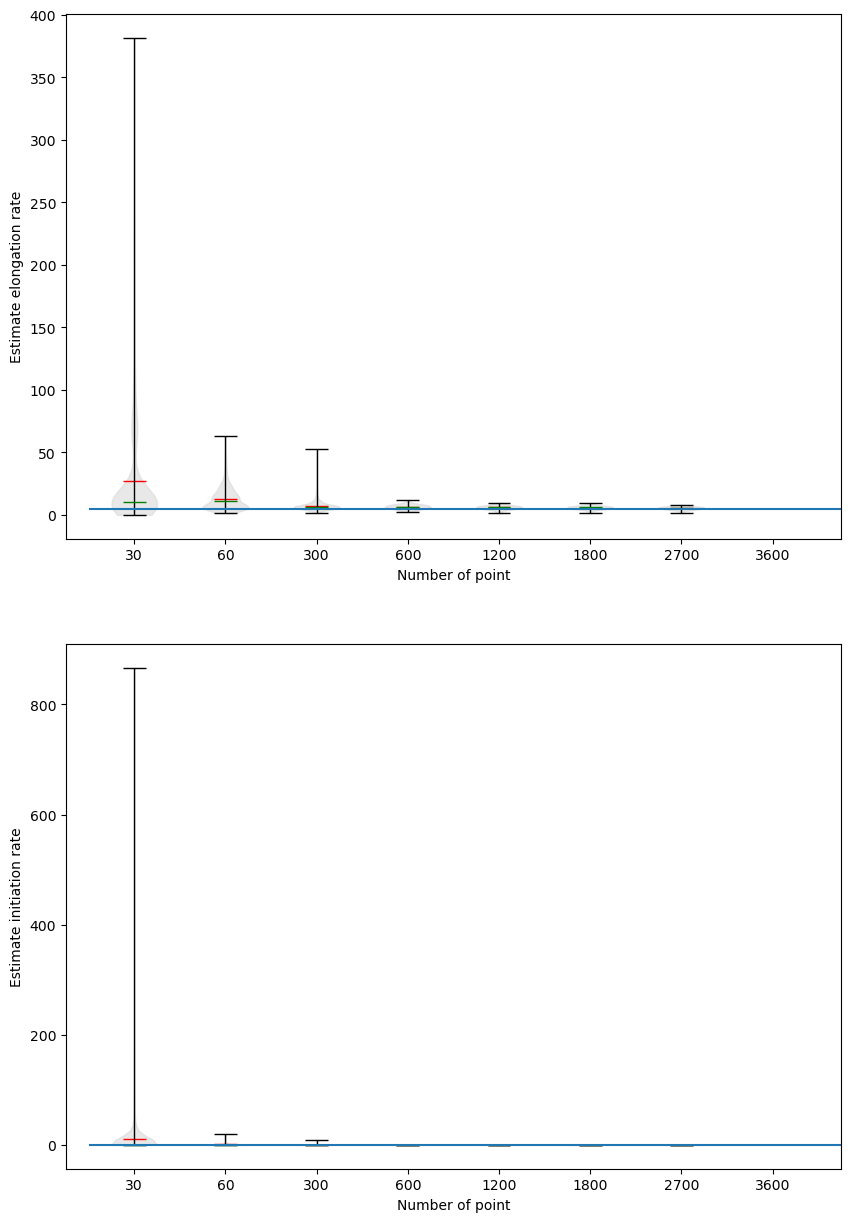

In [27]:
fig, ax = plt.subplots(2,1)


violin = ax[0].violinplot(dataset = [results[ (results.long_track == length_track)]["elongation_r"].values for length_track in [60, 300, 600, 1800, 3000, 3600, 6000]],
     showmeans=True,
      showmedians=True)

for pc in violin["bodies"]:
    pc.set_facecolor("lightgrey")
    pc.set_edgecolor("lightgrey")
    pc.set_alpha(0.5)
    
colors = ["black", "black", "black", "red", "green"]
i=0
for partname in ('cbars','cmins','cmaxes','cmeans','cmedians'):
    vp = violin[partname]
    vp.set_edgecolor(colors[i])
    vp.set_linewidth(1)
    i+=1
# results.boxplot(['init_translation_r'] , 
#                by=['dt', "long_track"], 
#                grid=False, 
#                ax = ax[1],
#                rot=90,
#                boxprops=dict(linestyle='-', linewidth=1.5, color="black"),
#                medianprops=dict(linestyle='-', linewidth=1.5, color="red"),
#                )


violin = ax[1].violinplot(dataset = [results[(results.long_track == length_track)]["init_translation_r"].values for length_track in [60, 300, 600, 1800, 3000, 3600, 6000]],
     showmeans=True,
      showmedians=True)

for pc in violin["bodies"]:
    pc.set_facecolor("lightgrey")
    pc.set_edgecolor("lightgrey")
    pc.set_alpha(0.5)
    
colors = ["black", "black", "black", "red", "green"]
i=0
for partname in ('cbars','cmins','cmaxes','cmeans','cmedians'):
    vp = violin[partname]
    vp.set_edgecolor(colors[i])
    vp.set_linewidth(1)
    i+=1

group = ['dt', "long_track"]
column = 'elongation_r'
grouped = results.groupby(group)
names, vals, xs = [], [] ,[]
for i, (name, subdf) in enumerate(grouped):
    if name[0] == 60:
        names.append(name)
        vals.append(subdf[column][subdf[column]>0].to_list())
        xs.append(np.random.normal(i+1-20, 0.04, subdf[column][subdf[column]>0].shape[0]))
clevels = np.linspace(0., 1., len(grouped))
for x, val, clevel in zip(xs, vals, clevels):
    ax[0].scatter(x, val, c='grey', alpha=1, s=10)
    
group = ['dt', "long_track"]
column = 'init_translation_r'
grouped = results.groupby(group)
names, vals, xs = [], [] ,[]
for i, (name, subdf) in enumerate(grouped):
    if name[0] == 60:
        names.append(name)
        vals.append(subdf[column][subdf[column]>0].to_list())
        xs.append(np.random.normal(i+1-20, 0.04, subdf[column][subdf[column]>0].shape[0]))
clevels = np.linspace(0., 1., len(grouped))
for x, val, clevel in zip(xs, vals, clevels):
    ax[1].scatter(x, val, c='grey', alpha=1, s=20)

def set_axis_style(ax, labels):
    ax.set_xticks(np.arange(1, len(labels) + 1), labels=labels)
    ax.set_xlim(0.25, len(labels) + 0.75)
    ax.set_xlabel('Number of point')
# set style for the axes
labels =[30,60,300,600,1200,1800,2700,3600]
for a in ax:
    set_axis_style(a, labels)

ax[0].set_ylabel("Estimate elongation rate")
ax[1].set_ylabel("Estimate initiation rate")

# ax[0].set_ylim(-5,50)
# ax[1].set_ylim(-1, 20)
ax[0].hlines(elongation_rate, 0.5, 9.5)
ax[1].hlines(0.05, 0.5, 9.5)
fig.set_size_inches((10,15))
# fig.savefig(os.path.join(path_save, "results_length_boxplot_exact_dt1_0.05_5.eps"), dpi=300)

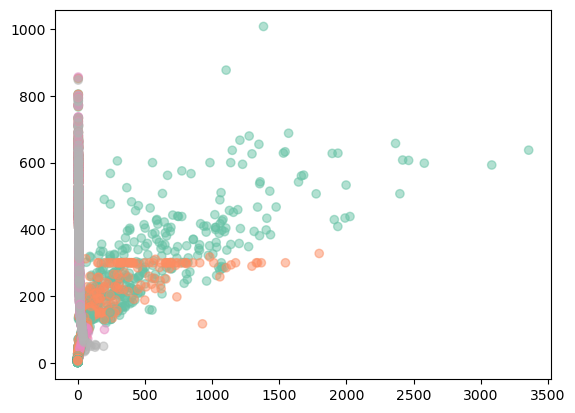

In [38]:
fig, ax = plt.subplots()
ax.scatter(results["init_translation_r"], results["elongation_r"], c=results["dt"],cmap="Set2", alpha=0.5)
# ax.set_xlim(-2,6)
# ax.set_ylim(-1,50)

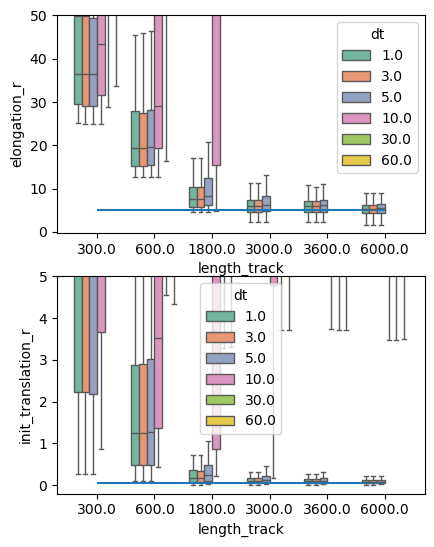

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [41]:
import seaborn as sns
results_crop = results[results["length_track"]>60]

fig, axes = plt.subplots(nrows=2)
sns.boxplot(x="length_track", y="elongation_r", hue="dt", data=results_crop, palette="Set2", showfliers=False, ax = axes[0])
axes[0].set_ylim(-0.2, 50)
axes[0].hlines(elongation_rate, 0.0, 5)

sns.boxplot(x="length_track", y="init_translation_r", hue="dt", data=results_crop, palette="Set2", showfliers=False, ax = axes[1])
axes[1].set_ylim(-0.2, 5)
axes[1].hlines(0.05, 0.0, 5)

fig.set_size_inches(2.37*2,6.21)
plt.show()
fig.savefig(os.path.join(path_save, "track_length_dt_v2_group_length_5aasec_200rep_epitope_long.eps"), dpi=300)

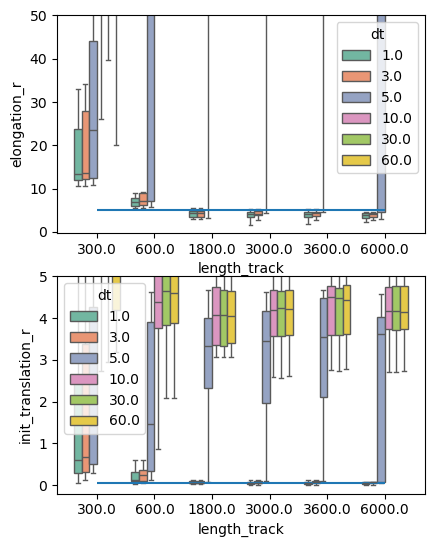

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [65]:
results = pd.read_csv(os.path.join(path, "results_dt_track_length_translation_rate_5_nb_point_approx.csv"), index_col="Unnamed: 0")
import seaborn as sns
results_crop = results[results["length_track"]>60]

fig, axes = plt.subplots(nrows=2)
sns.boxplot(x="length_track", y="elongation_r", hue="dt", data=results_crop, palette="Set2", showfliers=False, ax = axes[0])
axes[0].set_ylim(-0.2, 50)
axes[0].hlines(elongation_rate, 0.0, 5)

sns.boxplot(x="length_track", y="init_translation_r", hue="dt", data=results_crop, palette="Set2", showfliers=False, ax = axes[1])
axes[1].set_ylim(-0.2, 5)
axes[1].hlines(0.05, 0.0, 5)

fig.set_size_inches(2.37*2,6.21)
plt.show()
fig.savefig(os.path.join(path_save, "track_length_dt_v2_group_length_5aasec_20rep_approx.eps"), dpi=300)

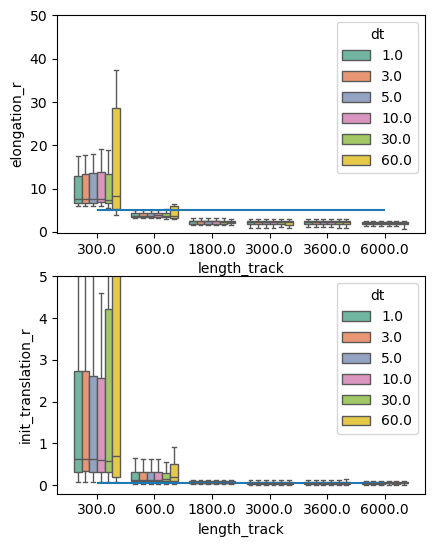

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [66]:
results = pd.read_csv(os.path.join(path, "results_dt_track_length_translation_rate_5_nb_point_epitope.csv"), index_col="Unnamed: 0")
import seaborn as sns
results_crop = results[results["length_track"]>60]

fig, axes = plt.subplots(nrows=2)
sns.boxplot(x="length_track", y="elongation_r", hue="dt", data=results_crop, palette="Set2", showfliers=False, ax = axes[0])
axes[0].set_ylim(-0.2, 50)
axes[0].hlines(elongation_rate, 0.0, 5)

sns.boxplot(x="length_track", y="init_translation_r", hue="dt", data=results_crop, palette="Set2", showfliers=False, ax = axes[1])
axes[1].set_ylim(-0.2, 5)
axes[1].hlines(0.05, 0.0, 5)

fig.set_size_inches(2.37*2,6.21)
plt.show()
fig.savefig(os.path.join(path_save, "track_length_dt_v2_group_length_5aasec_20rep_epitope.eps"), dpi=300)

In [46]:
pd.crosstab(results["length_track"], results["dt"], values=results["elongation_r"], aggfunc="mean")

dt,1.0,3.0,5.0,10.0,30.0,60.0
length_track,,,,,,
60.0,116.932962,268.568299,133.706476,493.768942,NaN,NaN
300.0,41.152341,41.107069,41.135659,40.916417,57.084075,109.571650
600.0,30.450503,30.551994,30.420268,30.598532,37.163794,78.641216
1800.0,25.460558,25.528780,25.405919,25.303151,26.123839,38.011440
3000.0,26.307416,26.345032,26.261554,26.167770,26.588210,24.549357
3600.0,25.828416,25.859569,25.815093,25.649836,26.206891,24.431090
6000.0,21.462904,21.555712,21.559523,21.255523,20.493873,18.545753


In [47]:
pd.crosstab(results["length_track"], results["dt"], values=results["init_translation_r"], aggfunc="mean")

dt,1.0,3.0,5.0,10.0,30.0,60.0
length_track,,,,,,
60.0,1.781709,1.895700,1.946880,4.724208,NaN,NaN
300.0,0.143542,0.142770,0.146505,0.151047,0.158079,0.549466
600.0,0.068426,0.068393,0.068699,0.070231,0.076603,0.181816
1800.0,0.052213,0.052255,0.052161,0.052133,0.053103,0.072425
3000.0,0.053698,0.053696,0.053609,0.053537,0.054461,0.049701
3600.0,0.054329,0.054280,0.054211,0.053955,0.054649,0.050554
6000.0,0.040741,0.040870,0.040868,0.040165,0.038604,0.031005


In [ ]:
import seaborn as sns

fig, axes = plt.subplots(nrows=2)
sns.boxplot(x="long_track", y="elongation_r", hue="dt", data=results, palette="Set1", showfliers=False, ax = axes[0])
# axes[0].set_ylim(-0.2, 50)
axes[0].hlines(elongation_rate, 0.0, 7)

sns.boxplot(x="long_track", y="init_translation_r", hue="dt", data=results, palette="Set1", showfliers=False, ax = axes[1])
# axes[1].set_ylim(-0.2, 1)
axes[1].hlines(0.05, 0.0, 7)

fig.set_size_inches(10,10)
plt.show()
# fig.savefig(os.path.join(path_save, "track_length_dt_v2.eps"), dpi=300)

In [ ]:
results[(results.dt == 60.0) & (results.long_track >1000) & (results.elongation_r>0)]

In [ ]:
results_group = results.groupby(["dt", "long_track"]).mean()
results_group.reset_index(inplace=True)

elongation_ref = 24

results_group["elongation_r_diff"] = elongation_ref-results_group['elongation_r']
results_group["elongation_r_ratio"] = 100*results_group["elongation_r"]/elongation_ref - 100
results_group["elongation_r_ratio"]= np.abs(results_group["elongation_r_ratio"])


results_group["init_translation_r_diff"] = 20-results_group['init_translation_r']
results_group["init_translation_r_ratio"] = 100*results_group["init_translation_r"]/20 -100
results_group["init_translation_r_ratio"] = np.abs(results_group["init_translation_r_ratio"])

results_group

In [ ]:
import seaborn as sns
from matplotlib.colors import ListedColormap
# Create a symmetric colormap
color = plt.cm.coolwarm
color_r = plt.cm.coolwarm_r
combined_colors = ListedColormap(color_r(np.linspace(0, 1, 128)).tolist() +
                                 color(np.linspace(0, 1, 128)).tolist())

heatmap_data = results_group.pivot(index='long_track', columns='dt', values='elongation_r_ratio')

# Create the heatmap
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(16, 6))
# plt.figure(figsize=(8, 6))
ax1 = sns.heatmap(heatmap_data, 
                 annot=True, 
                 fmt=".1f", 
                 cmap="PiYG_r",
                 vmin = 0,
                 vmax = 100,
                 ax=ax1)
# Invert the y-axis
ax1.invert_yaxis()
ax1.set_title("Heatmap of elongation rate Values")
ax1.set_xlabel("time step")
ax1.set_ylabel("track length")



heatmap_data = results_group.pivot(index='long_track', columns='dt', values='init_translation_r_ratio')
ax2 = sns.heatmap(heatmap_data, 
                 annot=True, 
                 fmt=".1f", 
                 cmap="PiYG_r",
                 vmin = 0,
                 vmax = 100, 
                  ax = ax2
                )
# Invert the y-axis
ax2.invert_yaxis()
ax2.set_title("Heatmap of initiation rate Values")
ax2.set_xlabel("time step")
ax2.set_ylabel("track length")

In [ ]:
import seaborn as sns
from matplotlib.colors import ListedColormap
# Create a symmetric colormap
color = plt.cm.coolwarm
color_r = plt.cm.coolwarm_r
combined_colors = ListedColormap(color_r(np.linspace(0, 1, 128)).tolist() +
                                 color(np.linspace(0, 1, 128)).tolist())

heatmap_data = results_group.pivot(index='long_track', columns='dt', values='init_translation_r_ratio')

# Create the heatmap
plt.figure(figsize=(8, 6))
ax = sns.heatmap(heatmap_data, 
                 annot=True, 
                 fmt=".1f", 
                 cmap=combined_colors,
                 vmin = 0,
                 vmax = 200
                )
# Invert the y-axis
ax.invert_yaxis()

plt.title("Heatmap of initiation rate Values")
plt.xlabel("time step")
plt.ylabel("track length")
plt.show()